In [2]:
import os
import sys
import argparse
import torch
import torch.nn as nn

from tqdm import tqdm
from pathlib import Path
from typing import List, Optional
from torch.utils.data import DataLoader
from src.models.our_method.older_surrogate import MultiHeadOlderSurrogate
from src.models.our_method.swin_cafm import SwinCAFM
from src.datasets.mos2_sef import MOS2SEFDataset, Formulation as F
from src.util.logger import ExperimentLogger
from src.util.loss import ImageInpaintingL1Loss
from src.util.config import (
    TrainConfig,
    ModelConfig,
    LOSS_FUNCTIONS,
    OPTIMIZERS,
    MODELS,
)

TRAIN_CONFIG_FP = os.path.abspath("configs/train.yaml")


def setup_logger(
    train_config: TrainConfig, model_config: Optional[ModelConfig]
) -> ExperimentLogger:
    logger = ExperimentLogger(
        train_config_dict=train_config.to_dict(),
        model_config_dict=model_config.to_dict() if model_config != None else None,
        root=train_config.log_root,
        exp_name=train_config.exp_name,
        log_interval=train_config.log_interval,
    )
    logger.add_result_columns(train_config.result_columns)
    return logger


def create_model(config: TrainConfig) -> nn.Module:
    model_fn = MODELS[config.model_name]["fn"]
    model_weights = MODELS[config.model_name]["weights"]
    if model_weights:
        model = model_fn(weights=model_weights)
    elif config.model_name == "hiera":
        model = model_fn
        model.freeze()
    else:
        model = model_fn()
    assert isinstance(model, nn.Module)
    return model.cuda(config.device).float()


def create_surrogate(config: TrainConfig) -> nn.Module:
    """
    Create an OLDER surrogate module.
    """
    surrogate_fn = MODELS[config.surrogate_name]["fn"]
    surrogate_weights = MODELS[config.surrogate_name]["weights"]
    surrogate: MultiHeadOlderSurrogate = surrogate_fn()
    if surrogate_weights:
        surrogate.load_state_dict(torch.load(surrogate_weights))
    assert isinstance(surrogate, MultiHeadOlderSurrogate)
    return surrogate.cuda(config.device).float()


def create_dataloader(config: TrainConfig, split: str) -> DataLoader:
    img_size = int(config.image_size)
    dataset = MOS2SEFDataset(
        split=split,
        side_length=int(config.crop_size),
        formulation=F.get_formulation_from_str(config.formulation),
        steps_per_epoch=(
            config.steps_per_epoch if split == "train" else config.val_steps_per_epoch
        ),
        device=config.device,
        original_image_size=(img_size, img_size),
        masking_ratio=int(config.masking_ratio),
    )
    return DataLoader(
        dataset,
        batch_size=config.train_batch_size,
        shuffle=False,
        num_workers=config.num_workers,
    )

In [3]:
# load training config
config = TrainConfig(TRAIN_CONFIG_FP)
model_config: Optional[ModelConfig] = None

# optional: parse model config
if config.model_config_file != None:
    model_config_abs_path = os.path.join(
        Path(TRAIN_CONFIG_FP).parent.__str__(), config.model_config_file
    )
    assert os.path.isfile(
        model_config_abs_path
    ), f"Bad path to model config: {model_config_abs_path}"
    model_config = ModelConfig(model_config_abs_path)

# -------------------- training config args --------------------
config.surgate_weights = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/e. surrogate standalone train-runs/2025-02-08_12-36-35_older_surrogate_mh-ViT-l[-2]+layernorm/older_surrogate_mh-ViT-l[-2]+layernorm_latest_older_surrogate.pth"

In [6]:
model = create_model(config)
surrogate: MultiHeadOlderSurrogate = create_surrogate(config)

train_dataloader = create_dataloader(config, "train")
val_dataloader = create_dataloader(config, "val")

# define loss function and optimizer
train_loss: torch.nn.Module = LOSS_FUNCTIONS[config.train_loss]()
val_loss: torch.nn.Module = LOSS_FUNCTIONS[config.val_loss]()

# use to save model checkpoints
best_val_loss = sys.maxsize

num_epochs = config.epochs
device = config.device

# load weights from checkpoint
if config.weights != None:
    # load enitre model object:
    model = torch.load(config.weights).float().cuda()

optimizer: torch.optim.Optimizer = OPTIMIZERS[config.optimizer](
    model.parameters(), lr=float(config.learning_rate)
)

model.cuda(device)
model.float()

# surrogate model is used purely as an evaluator
surrogate.eval();

In [7]:
num_epochs=1
older_losses = []

# ---------- training loop ----------
for epoch in range(num_epochs):

    model.train()

    for i, batch in enumerate(
        tqdm(train_dataloader, desc=f"Training: Epoch {epoch+1}/{num_epochs}")
    ):
        # topo-map:    X
        X: torch.Tensor = batch["X"].cuda(device)

        # current-map: y
        y: torch.Tensor = batch["y"].cuda(device)

        # ---- remove masked pixels ----
        mask: torch.Tensor = batch["mask"].cuda(device)
        y_sparse = (y * mask).float()

        # zero gradients
        optimizer.zero_grad()

        # ---- forward: p(y | y_sparse) ----
        outputs = model(y_sparse)

        # final model prediction with given unmasked pixels
        y_hat = ImageInpaintingL1Loss.get_final_prediction(
            predicted_image=outputs, target_image=y, mask=mask
        )

        # NOTE: standard loss (e.g., L1)
        char_1 = surrogate(y); char_2 = surrogate(y_hat)
        
        # NOTE: raw model outputs
        # --- Loss: L1 ---
        # loss: torch.Tensor = torch.nn.functional.l1_loss(y, outputs)
        # --- Loss: OLDER ---
        loss: torch.Tensor = train_loss(char_1, char_2)
        # --- Loss: OLDER + L1 ---
        # loss: torch.Tensor = train_loss(char_1, char_2) + torch.nn.functional.l1_loss(y, outputs)
        
        # NOTE: final pred
        # --- Loss: L1 ---
        # loss: torch.Tensor = torch.nn.functional.l1_loss(y, y_hat)
        # --- Loss: OLDER ---
        # loss: torch.Tensor = train_loss(char_1, char_2)
        # --- Loss: OLDER + L1 ---
        # loss: torch.Tensor = train_loss(char_1, char_2) + torch.nn.f
        # unctional.l1_loss(y, outputs)
        
        loss.backward()
        older_losses.append(loss.item())
        optimizer.step()

Training: Epoch 1/1: 100%|██████████| 1024/1024 [04:15<00:00,  4.01it/s]


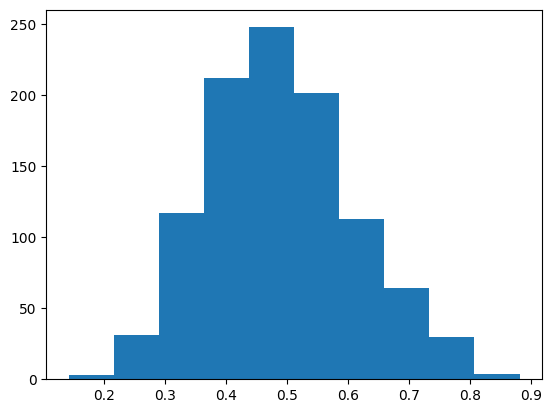

In [9]:
import matplotlib.pyplot as plt
plt.hist(older_losses);

In [ ]:
# validation
model.eval()
val_running_loss = 0.0
num_val_steps = 1

with torch.no_grad():
    for i, batch in enumerate(
        tqdm(val_dataloader, desc=f"Validation: Epoch {epoch+1}/{num_epochs}")
    ):
        # topo-map:    X
        X: torch.Tensor = batch["X"].cuda(device)

        # current-map: y
        y: torch.Tensor = batch["y"].cuda(device)

        # ---- remove masked pixels ----
        mask: torch.Tensor = batch["mask"].cuda(device)
        y_sparse = (y * mask).float()

        # ---- forward: p(y | y_sparse) ----
        outputs = model(y_sparse)

        # final model prediction with given unmasked pixels
        y_hat = ImageInpaintingL1Loss.get_final_prediction(
            predicted_image=outputs, target_image=y, mask=mask
        )

        # NOTE: standard loss (e.g., L1)
        # loss: torch.Tensor = train_loss(outputs, y))
        char_1 = surrogate(y); char_2 = surrogate(y_hat)
        
        # Loss: L1
        loss: torch.Tensor = torch.nn.functional.l1_loss(y, outputs)
        # Loss: OLDER
        # loss: torch.Tensor = train_loss(char_1, char_2)
        # Loss: OLDER + L1
        # loss: torch.Tensor = train_loss(char_1, char_2) + torch.nn.functional.l1_loss(y, outputs)

        val_running_loss += loss.item() * y_sparse.size(0)

    # optional: log best/recent model weights
    avg_val_loss = val_running_loss / num_val_steps
